# Notebook 3: Explainability — SHAP & LIME
## Transparent AI for Clinical Decision Support

This notebook covers:
1. SHAP global and local explanations
2. LIME local explanations
3. SHAP vs LIME comparison
4. LIME stability analysis
5. Saving explainer artifacts for deployment

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from lime import lime_tabular

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Model & Data

In [2]:
# Load processed data
with open('../models/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_resampled = data['X_train_resampled']
y_train_resampled = data['y_train_resampled']
X_test_processed = data['X_test_processed']
y_test = data['y_test']
feature_cols = data['feature_cols']

# Load best model (Random Forest)
with open('../models/best_model_v2.pkl', 'rb') as f:
    model = pickle.load(f)

y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

print(f"Model: {type(model).__name__}")
print(f"Test set: {X_test_processed.shape}")

Model: RandomForestClassifier
Test set: (848, 13)


## 2. SHAP Analysis

In [3]:
# Initialize SHAP explainer based on model type
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

if isinstance(model, (RandomForestClassifier, xgb.XGBClassifier)):
    explainer = shap.TreeExplainer(model)
elif isinstance(model, LogisticRegression):
    explainer = shap.LinearExplainer(model, X_train_resampled)
else:
    explainer = shap.KernelExplainer(model.predict_proba, shap.sample(X_train_resampled, 100))

shap_values = explainer.shap_values(X_test_processed)

# Handle 3D array (n_samples, n_features, n_classes) from TreeExplainer
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]  # class 1 (CHD)
elif isinstance(shap_values, list):
    shap_values = shap_values[1]  # class 1 (CHD)

# Handle expected_value similarly
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(expected_value[1])

print(f"SHAP explainer type: {type(explainer).__name__}")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate): {expected_value:.4f}")


SHAP explainer type: TreeExplainer
SHAP values shape: (848, 13)
Expected value (base rate): 0.4443


C:\Users\Danila\AppData\Local\Temp\ipykernel_15316\792747624.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_processed, plot_type="bar", show=False)


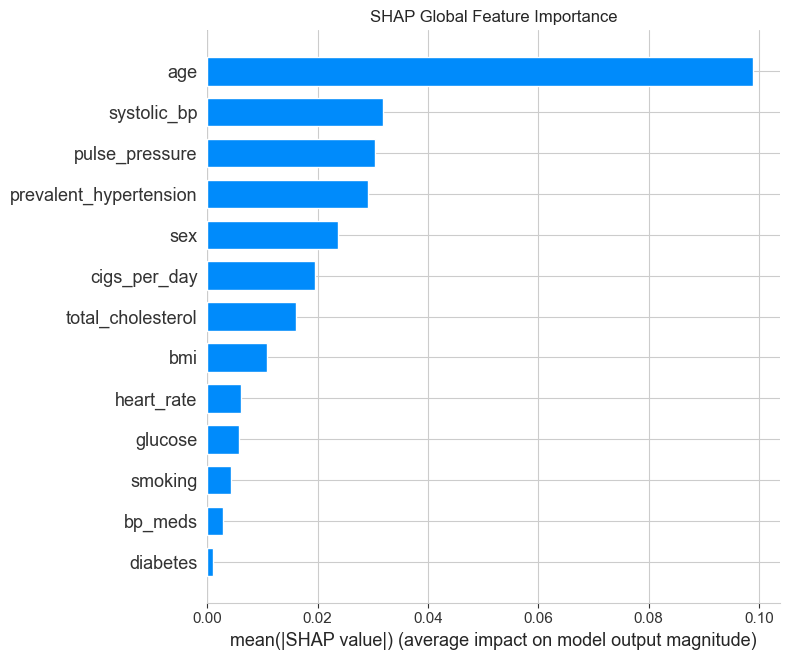

In [4]:
# Global Feature Importance (bar plot)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, plot_type="bar", show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
plt.show()

C:\Users\Danila\AppData\Local\Temp\ipykernel_15316\893472680.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_processed, show=False)


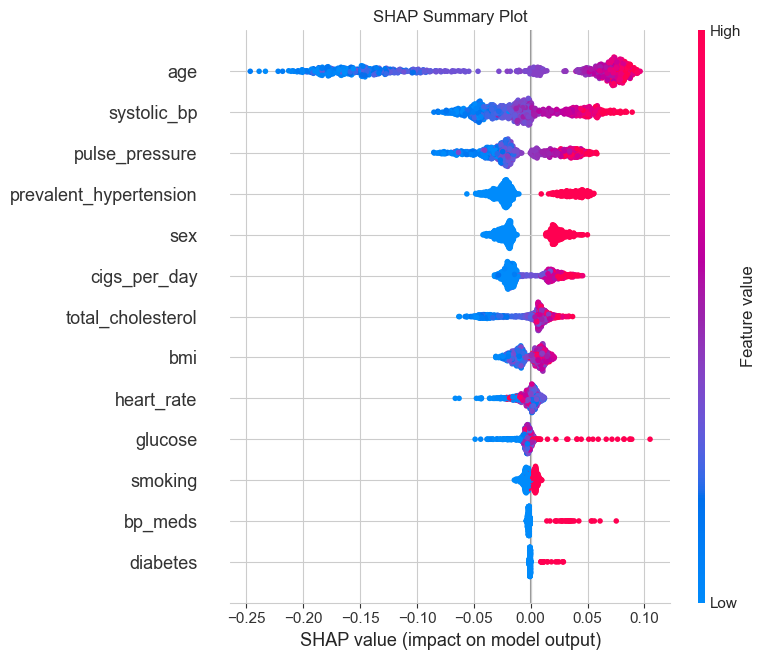

In [5]:
# SHAP Summary Plot (beeswarm — shows feature value direction)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

High-risk patient index: 792
Predicted probability: 0.7552
Actual label: 1


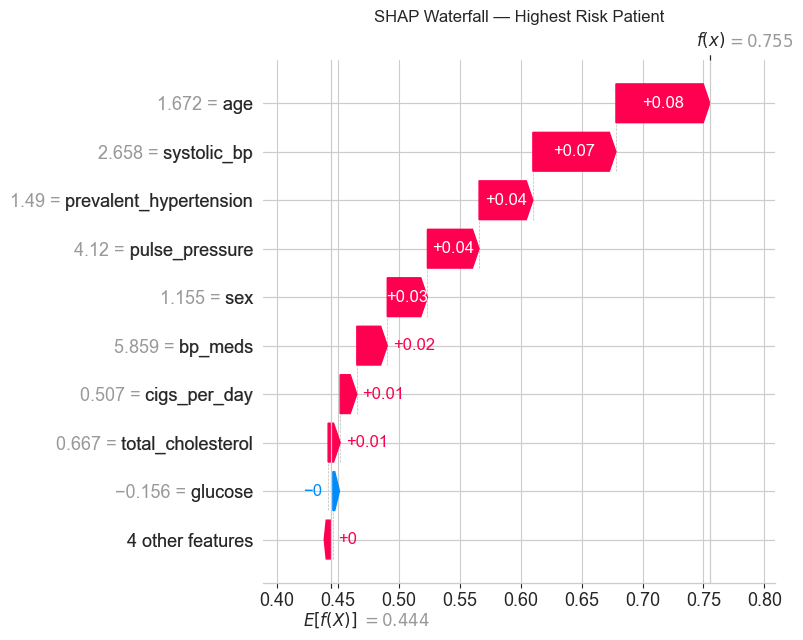

In [6]:
# Local explanation: highest-risk patient
high_risk_idx = np.argmax(y_pred_proba)
print(f"High-risk patient index: {high_risk_idx}")
print(f"Predicted probability: {y_pred_proba[high_risk_idx]:.4f}")
print(f"Actual label: {y_test.iloc[high_risk_idx]}")

# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=expected_value,
        data=X_test_processed.iloc[high_risk_idx],
        feature_names=feature_cols
    ),
    show=False
)
plt.title('SHAP Waterfall — Highest Risk Patient')
plt.tight_layout()
plt.show()

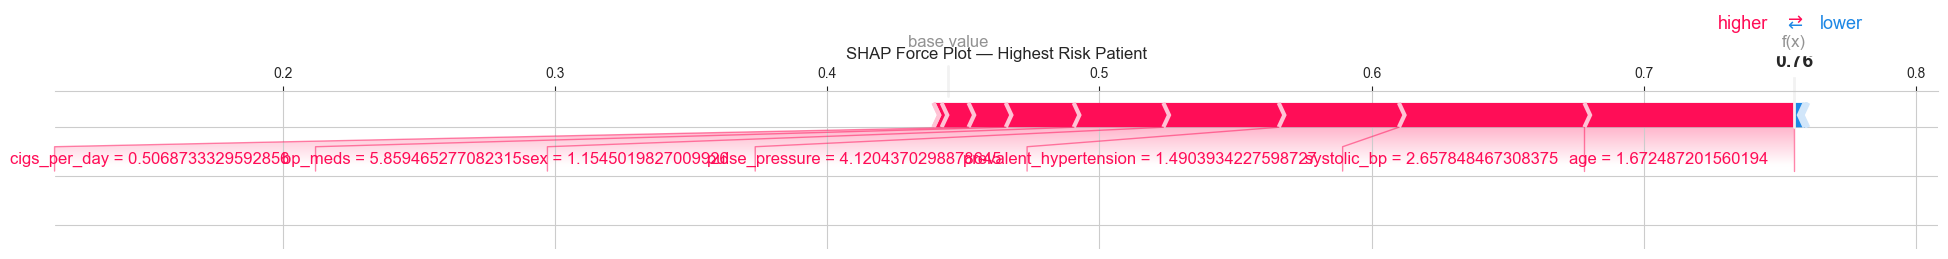

In [7]:
# Force plot for the same patient
shap.force_plot(
    expected_value,
    shap_values[high_risk_idx],
    X_test_processed.iloc[high_risk_idx],
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot — Highest Risk Patient')
plt.tight_layout()
plt.show()

## 3. LIME Analysis

D:\Capstone\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


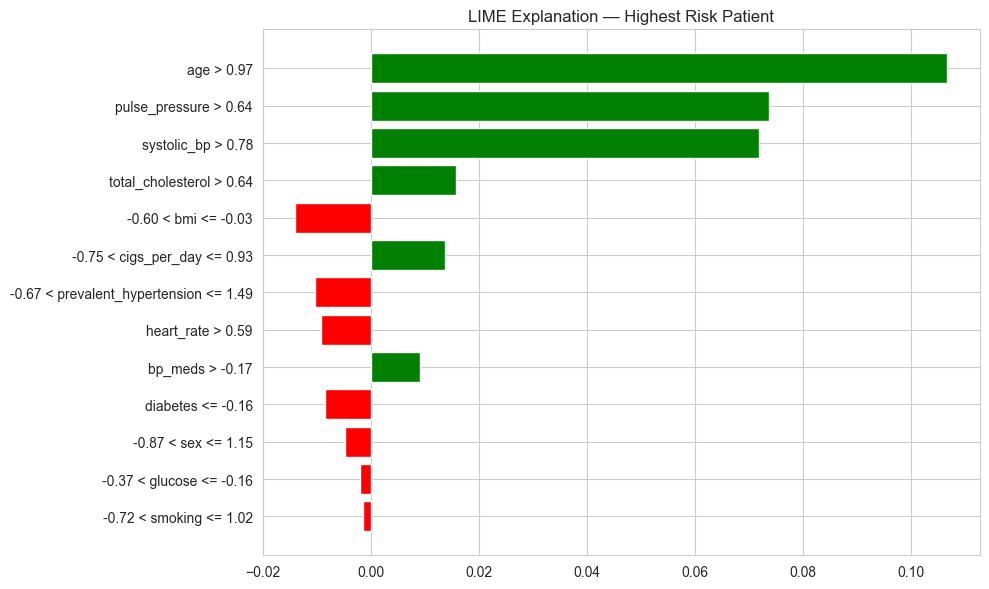

In [8]:
# Initialize LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values if isinstance(X_train_resampled, pd.DataFrame) else X_train_resampled,
    feature_names=feature_cols,
    class_names=['No CHD', 'CHD'],
    mode='classification',
    random_state=RANDOM_STATE
)

# Explain the same high-risk patient
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_processed.iloc[high_risk_idx].values,
    predict_fn=model.predict_proba,
    num_features=len(feature_cols)
)

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title('LIME Explanation — Highest Risk Patient')
plt.tight_layout()
plt.show()

## 4. SHAP vs LIME Comparison

In [9]:
def get_top_shap_features(shap_vals, feature_names, n=5):
    """Get top N features by absolute SHAP value."""
    abs_shap = np.abs(shap_vals)
    top_indices = np.argsort(abs_shap)[-n:][::-1]
    return [(feature_names[i], shap_vals[i]) for i in top_indices]

def get_top_lime_features(lime_explanation, n=5):
    """Get top N features from LIME explanation."""
    return lime_explanation.as_list()[:n]

shap_top = get_top_shap_features(shap_values[high_risk_idx], feature_cols, n=5)
lime_top = get_top_lime_features(lime_exp, n=5)

print("Top 5 SHAP features:")
for feat, val in shap_top:
    print(f"  {feat}: {val:.4f}")

print("\nTop 5 LIME features:")
for feat_rule, val in lime_top:
    print(f"  {feat_rule}: {val:.4f}")

# Overlap analysis
shap_feat_names = {f for f, _ in shap_top}
lime_feat_names = set()
for feat_rule, _ in lime_top:
    for fc in feature_cols:
        if fc in feat_rule:
            lime_feat_names.add(fc)
            break

overlap = shap_feat_names & lime_feat_names
print(f"\nOverlap in top-5 features: {len(overlap)}/{5} — {overlap}")

Top 5 SHAP features:
  age: 0.0770
  systolic_bp: 0.0682
  prevalent_hypertension: 0.0442
  pulse_pressure: 0.0424
  sex: 0.0329

Top 5 LIME features:
  age > 0.97: 0.1067
  pulse_pressure > 0.64: 0.0736
  systolic_bp > 0.78: 0.0718
  total_cholesterol > 0.64: 0.0156
  -0.60 < bmi <= -0.03: -0.0141

Overlap in top-5 features: 3/5 — {'pulse_pressure', 'age', 'systolic_bp'}


## 5. LIME Stability Analysis

In [10]:
def lime_stability_test(explainer, instance, predict_fn, n_runs=5, num_features=11):
    """Run LIME multiple times and measure explanation consistency."""
    explanations = []
    for i in range(n_runs):
        exp = explainer.explain_instance(
            data_row=instance,
            predict_fn=predict_fn,
            num_features=num_features
        )
        explanations.append(dict(exp.as_list()))
    return explanations

stability_results = lime_stability_test(
    lime_explainer,
    X_test_processed.iloc[high_risk_idx].values,
    model.predict_proba,
    n_runs=5
)

# Analyze stability: coefficient of variation for each feature rule
all_keys = set()
for exp in stability_results:
    all_keys.update(exp.keys())

stability_df = pd.DataFrame(stability_results).reindex(columns=sorted(all_keys))
mean_vals = stability_df.mean()
std_vals = stability_df.std()
cv = (std_vals / mean_vals.abs().replace(0, np.nan)).abs()

print("LIME Stability (5 runs):")
print(f"  Mean coefficient of variation: {cv.mean():.4f}")
print(f"  Max coefficient of variation:  {cv.max():.4f}")
print("\nPer-feature CV:")
print(cv.sort_values(ascending=False).to_string())

D:\Capstone\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\Capstone\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


D:\Capstone\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\Capstone\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME Stability (5 runs):
  Mean coefficient of variation: 5.6734
  Max coefficient of variation:  66.3121

Per-feature CV:
heart_rate > 0.59                         66.312051
-0.72 < smoking <= 1.02                    4.785557
diabetes <= -0.16                          0.508520
-0.60 < bmi <= -0.03                       0.413467
-0.67 < prevalent_hypertension <= 1.49     0.361591
-0.75 < cigs_per_day <= 0.93               0.313103
-0.37 < glucose <= -0.16                   0.274080
total_cholesterol > 0.64                   0.262879
bp_meds > -0.17                            0.245595
-0.87 < sex <= 1.15                        0.107499
pulse_pressure > 0.64                      0.078448
systolic_bp > 0.78                         0.068399
age > 0.97                                 0.023606


D:\Capstone\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 6. Save Explainer Artifacts

In [11]:
# Save SHAP explainer
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# LIME explainer contains lambdas that can't be pickled directly.
# Save its configuration so it can be reconstructed in the webapp.
lime_config = {
    'training_data': X_train_resampled.values if isinstance(X_train_resampled, pd.DataFrame) else X_train_resampled,
    'feature_names': feature_cols,
    'class_names': ['No CHD', 'CHD'],
    'mode': 'classification',
    'random_state': RANDOM_STATE
}
with open('../models/lime_config.pkl', 'wb') as f:
    pickle.dump(lime_config, f)

print("Saved: models/shap_explainer.pkl")
print("Saved: models/lime_config.pkl (reconstruct with LimeTabularExplainer(**config))")
print("\nAll explainability artifacts ready for deployment.")

Saved: models/shap_explainer.pkl
Saved: models/lime_config.pkl (reconstruct with LimeTabularExplainer(**config))

All explainability artifacts ready for deployment.
